# Mobile Companion Robot

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal

plt.style.use("seaborn-v0_8")

# Physical parameters
b = 0.5
m = 1.0
k = 0.2

In [ ]:
# State: [g, v_r] (gap, robot velocity)
# Input: [u, v_user] (robot force, user velocity)
A = np.array([[0, -1], [k / m, -b / m]])
B = np.array([[0, 1], [1 / m, 0]])
C = np.array([[1, 0]])
D = np.array([[0, 0]])

sys = signal.StateSpace(A, B, C, D)

In [ ]:
t = np.linspace(0, 100, 101)
u = np.zeros((len(t), 2))
u[10:20, 0] = 1.0
u[40:50, 0] = 2.0
t, y, x = signal.lsim(sys, u, t)

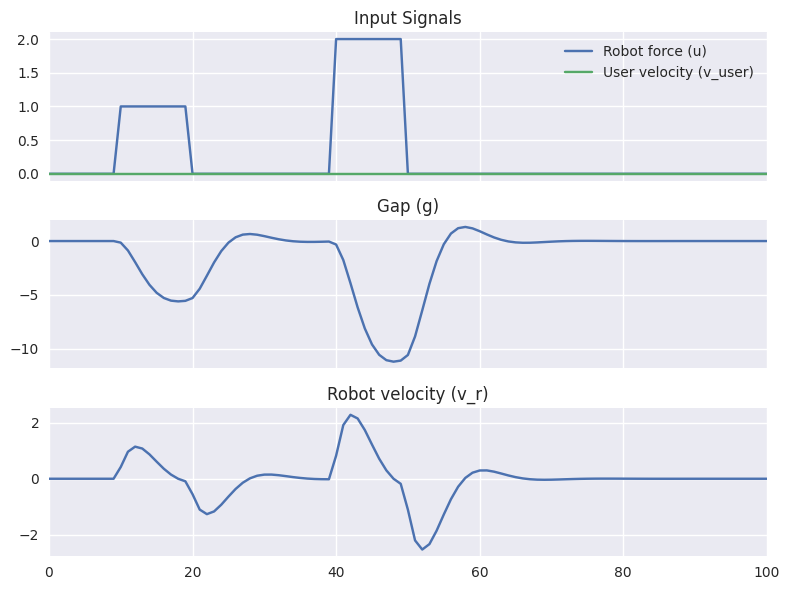

In [20]:
# Plot inputs and states
fig, ax = plt.subplots(3, 1, figsize=(8, 6), sharex=True)

ax[0].plot(t, u[:, 0], label="Robot force (u)")
ax[0].plot(t, u[:, 1], label="User velocity (v_user)")
ax[0].set_title("Input Signals")
ax[0].set_xlim(0, 100)
ax[0].legend()

ax[1].plot(t, x[:, 0])
ax[1].set_title("Gap (g)")
ax[1].set_xlim(0, 100)

ax[2].plot(t, x[:, 1])
ax[2].set_title("Robot velocity (v_r)")
ax[2].set_xlim(0, 100)

plt.tight_layout()
plt.show()

# Qualities

In [21]:
# Stability analysis
eigs = np.linalg.eigvals(A)
for i, e in enumerate(eigs):
    print(f"eigs[{i}]: {e.real:.2f}{e.imag:+.2f}j")

eigs[0]: -0.25+0.37j
eigs[1]: -0.25-0.37j


In [ ]:
# Reachability analysis
R = np.hstack([B, A @ B])
print("Reachability matrix R:")
print(R)

rank_R = np.linalg.matrix_rank(R)
print(f"Rank of R: {rank_R}")
# Reachability matrix R:
# [[ 0.   1.  -1.   0. ]
#  [ 1.   0.  -0.5  0.2]]
# Rank of R: 2

Reachability matrix R:
[[ 0.   1.  -1.   0. ]
 [ 1.   0.  -0.5  0.2]]
Rank of R: 2


In [ ]:
# Observability analysis
O = np.vstack([C, C @ A])
print("Observability matrix O:")
print(O)

rank_O = np.linalg.matrix_rank(O)
print(f"Rank of O: {rank_O}")
# Observability matrix O:
# [[ 1.  0.]
#  [ 0. -1.]]
# Rank of O: 2

Observability matrix O:
[[ 1.  0.]
 [ 0. -1.]]
Rank of O: 2
